Problem 1

  1-1  Entropy (no pruning)
  Metric              Train       Test
  ------------------------------------
  Error              0.0003     0.0803
  Accuracy           0.9997     0.9197
  F1                 0.9997     0.8984
  Auc                1.0000     0.9164
  Depth: 22   Leaves: 189
  1-2  Gini (no pruning)
  Metric              Train       Test
  ------------------------------------
  Error              0.0003     0.0890
  Accuracy           0.9997     0.9110
  F1                 0.9997     0.8877
  Auc                1.0000     0.9078
  Depth: 32   Leaves: 237

  Optimal depth (min test error): 11  (test error = 0.0695)


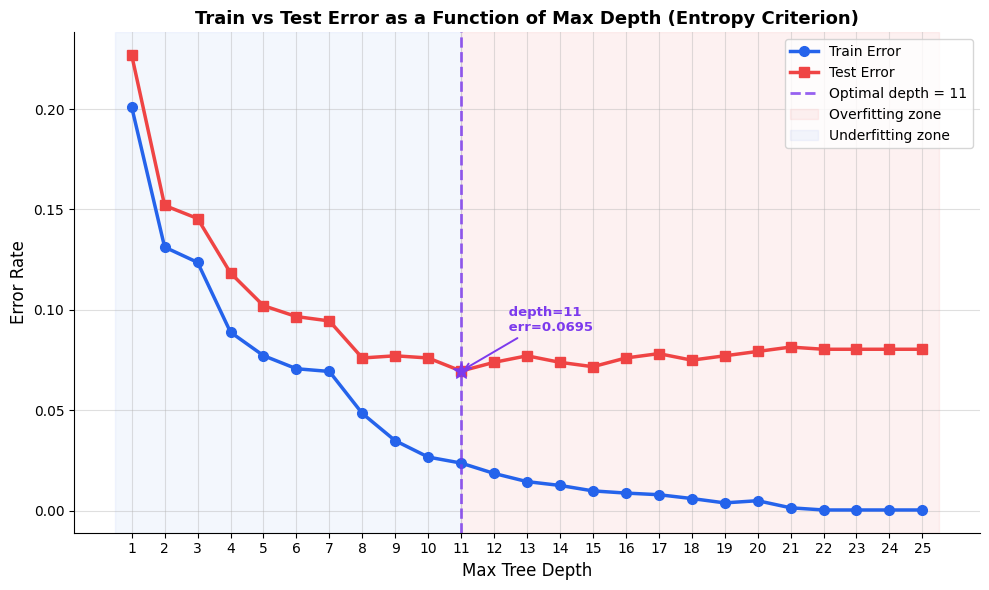


   Depth   Train Err    Test Err
  ------------------------------------
       1      0.2011      0.2269
       2      0.1312      0.1520
       3      0.1236      0.1455
       4      0.0889      0.1183
       5      0.0772      0.1021
       6      0.0707      0.0966
       7      0.0693      0.0945
       8      0.0484      0.0760
       9      0.0348      0.0771
      10      0.0266      0.0760
      11      0.0236      0.0695  <- OPTIMAL
      12      0.0185      0.0738
      13      0.0144      0.0771
      14      0.0125      0.0738
      15      0.0098      0.0717
      16      0.0087      0.0760
      17      0.0079      0.0782
      18      0.0060      0.0749
      19      0.0038      0.0771
      20      0.0049      0.0793
      21      0.0014      0.0814
      22      0.0003      0.0803
      23      0.0003      0.0803
      24      0.0003      0.0803
      25      0.0003      0.0803


In [36]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("/Users/etsub/Downloads/data/spambase.data", header=None)
X = df.iloc[:, :57].values
y = df.iloc[:, 57].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

def evaluate(model, X_tr, y_tr, X_te, y_te):
    out = {}
    for tag, Xd, yd in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        yp  = model.predict(Xd)
        ypr = model.predict_proba(Xd)[:, 1]
        out[tag] = dict(
            error    = round(1 - accuracy_score(yd, yp), 4),
            accuracy = round(accuracy_score(yd, yp),     4),
            f1       = round(f1_score(yd, yp),           4),
            auc      = round(roc_auc_score(yd, ypr),     4),
        )
    return out

def print_metrics(res, title):
    print(f"  {title}")
    print(f"  {'Metric':<14} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*36}")
    for m in ("error", "accuracy", "f1", "auc"):
        print(f"  {m.capitalize():<14} {res['Train'][m]:>10.4f} {res['Test'][m]:>10.4f}")

# 1-1 
dt_ent = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_ent.fit(X_train, y_train)
res_ent = evaluate(dt_ent, X_train, y_train, X_test, y_test)
print_metrics(res_ent, "1-1  Entropy (no pruning)")
print(f"  Depth: {dt_ent.get_depth()}   Leaves: {dt_ent.get_n_leaves()}")

# 1-2 
dt_gin = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gin.fit(X_train, y_train)
res_gin = evaluate(dt_gin, X_train, y_train, X_test, y_test)
print_metrics(res_gin, "1-2  Gini (no pruning)")
print(f"  Depth: {dt_gin.get_depth()}   Leaves: {dt_gin.get_n_leaves()}")

# 1-3 
depths       = list(range(1, 26))
train_errors = []
test_errors  = []

for d in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_errors.append(1 - accuracy_score(y_train, clf.predict(X_train)))
    test_errors.append( 1 - accuracy_score(y_test,  clf.predict(X_test)))

best_depth    = depths[np.argmin(test_errors)]
best_test_err = min(test_errors)
print(f"\n  Optimal depth (min test error): {best_depth}  (test error = {best_test_err:.4f})")

# Plot: train vs test error as a function of max depth
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_errors, "o-", color="#2563EB", lw=2.5, ms=7, label="Train Error")
ax.plot(depths, test_errors,  "s-", color="#EF4444", lw=2.5, ms=7, label="Test Error")
ax.axvline(best_depth, color="#7C3AED", lw=2, ls="--", alpha=0.8, label=f"Optimal depth = {best_depth}")
ax.scatter([best_depth], [best_test_err], color="#7C3AED", s=140, zorder=5, marker="*")
ax.annotate(f" depth={best_depth}\n err={best_test_err:.4f}",
            xy=(best_depth, best_test_err),
            xytext=(best_depth + 1.3, best_test_err + 0.02),
            fontsize=9.5, color="#7C3AED", fontweight="700",
            arrowprops=dict(arrowstyle="->", color="#7C3AED", lw=1.4))
ax.axvspan(best_depth, max(depths) + 0.5, alpha=0.07, color="#EF4444", label="Overfitting zone")
ax.axvspan(0.5, best_depth, alpha=0.05, color="#2563EB", label="Underfitting zone")
ax.set_xlabel("Max Tree Depth", fontsize=12)
ax.set_ylabel("Error Rate", fontsize=12)
ax.set_title("Train vs Test Error as a Function of Max Depth (Entropy Criterion)", fontsize=13, fontweight="bold")
ax.set_xticks(depths)
ax.legend(fontsize=10)
ax.grid(alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Depth table
print(f"\n  {'Depth':>6}  {'Train Err':>10}  {'Test Err':>10}")
print(f"  {'-'*36}")
for d, tr, te in zip(depths, train_errors, test_errors):
    marker = "  <- OPTIMAL" if d == best_depth else ""
    print(f"  {d:>6}  {tr:>10.4f}  {te:>10.4f}{marker}")

Problem 2

  Problem 2-1 : Random Forest – varying number of trees
      T  Split     Accuracy          F1         AUC
  ----------------------------------------------------
     10  Train       0.9954      0.9941      0.9999
     10  Test        0.9425      0.9250      0.9797
  ----------------------------------------------------
     50  Train       0.9997      0.9997      1.0000
     50  Test        0.9425      0.9252      0.9827
  ----------------------------------------------------
    100  Train       0.9997      0.9997      1.0000
    100  Test        0.9446      0.9283      0.9834
  ----------------------------------------------------
    500  Train       0.9997      0.9997      1.0000
    500  Test        0.9457      0.9298      0.9836
  ----------------------------------------------------
  Problem 2-2 : RF vs Decision Trees – TEST SET
  Model                           Accuracy          F1         AUC
  --------------------------------------------------------------
  DT Entropy (no prun

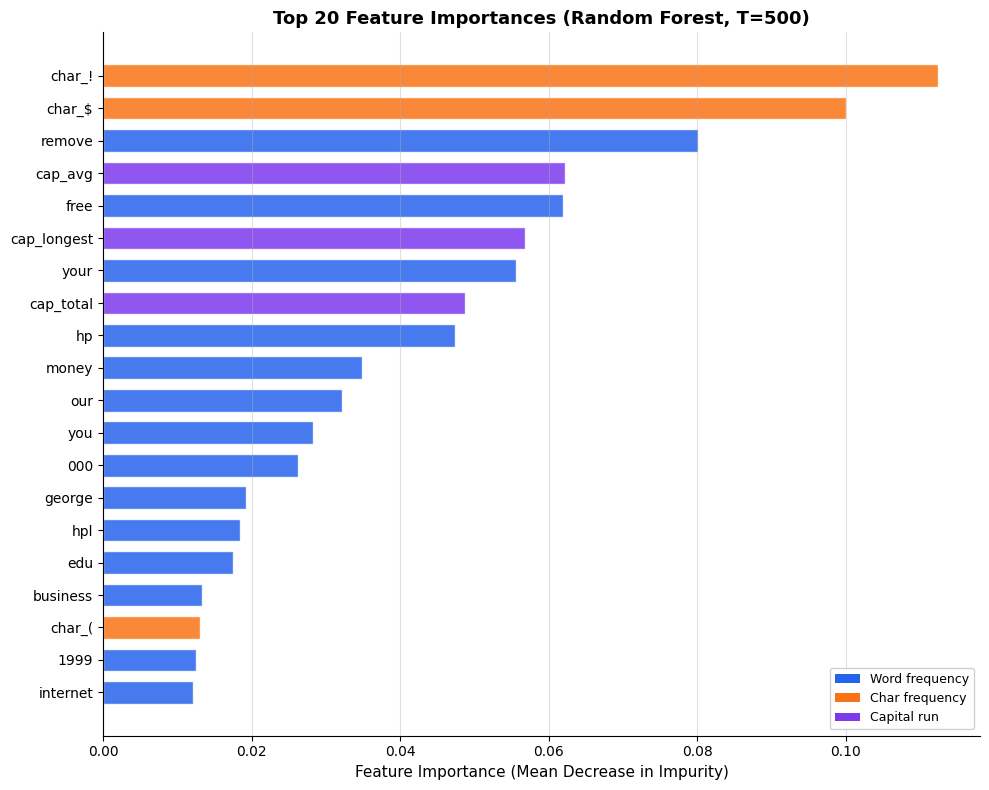


  Top 10 Most Important Features (RF T=500)
   Rank  Feature               Importance
  ----------------------------------------
      1  char_!                    0.1124
      2  char_$                    0.1000
      3  remove                    0.0801
      4  cap_avg                   0.0621
      5  free                      0.0619
      6  cap_longest               0.0568
      7  your                      0.0557
      8  cap_total                 0.0488
      9  hp                        0.0474
     10  money                     0.0348


In [28]:

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("/Users/etsub/Downloads/data/spambase.data", header=None)
X = df.iloc[:, :57].values
y = df.iloc[:, 57].values

# Feature names (from UCI SPAMBASE documentation)
word_feats  = ["make","address","all","3d","our","over","remove","internet","order","mail",
               "receive","will","people","report","addresses","free","business","email","you",
               "credit","your","font","000","money","hp","hpl","george","650","lab","labs",
               "telnet","857","data","415","85","technology","1999","parts","pm","direct",
               "cs","meeting","original","project","re","edu","table","conference"]
char_feats  = ["char_;","char_(","char_[","char_!","char_$","char_#"]
other_feats = ["cap_avg","cap_longest","cap_total"]
feature_names = (word_feats + char_feats + other_feats)[:57]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

def get_metrics(model, Xd, yd):
    yp  = model.predict(Xd)
    ypr = model.predict_proba(Xd)[:, 1]
    return dict(
        accuracy = round(accuracy_score(yd, yp), 4),
        f1       = round(f1_score(yd, yp),       4),
        auc      = round(roc_auc_score(yd, ypr),  4),
    )

T_values   = [10, 50, 100, 500]
rf_results = {}

# 2-1
print(f" Random Forest, varying number of trees")
print(f"  {'T':>5}  {'Split':<6}  {'Accuracy':>10}  {'F1':>10}  {'AUC':>10}")
print(f"  {'-'*52}")

for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_results[T] = {"model": rf,
                     "train": get_metrics(rf, X_train, y_train),
                     "test":  get_metrics(rf, X_test,  y_test)}
    for split, m in [("Train", rf_results[T]["train"]), ("Test", rf_results[T]["test"])]:
        print(f"  {T:>5}  {split:<6}  {m['accuracy']:>10.4f}  {m['f1']:>10.4f}  {m['auc']:>10.4f}")
    print(f"  {'-'*52}")

# Compare RF vs Decision Trees
dt_ent    = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_pruned = DecisionTreeClassifier(criterion="entropy", max_depth=11, random_state=42)
dt_ent.fit(X_train, y_train)
dt_pruned.fit(X_train, y_train)

rows = [
    ("DT Entropy (no pruning)", get_metrics(dt_ent,    X_test, y_test)),
    ("DT Entropy (depth=11)",   get_metrics(dt_pruned, X_test, y_test)),
    ("RF T=10",                 rf_results[10]["test"]),
    ("RF T=50",                 rf_results[50]["test"]),
    ("RF T=100",                rf_results[100]["test"]),
    ("RF T=500",                rf_results[500]["test"]),
]

print(f" RF vs Decision Trees, TEST SET")
print(f"  {'Model':<28}  {'Accuracy':>10}  {'F1':>10}  {'AUC':>10}")
print(f"  {'-'*62}")
for name, m in rows:
    print(f"  {name:<28}  {m['accuracy']:>10.4f}  {m['f1']:>10.4f}  {m['auc']:>10.4f}")

# 2-3
best_rf     = rf_results[500]["model"]
importances = best_rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
top_n       = 20

top_names  = [feature_names[i] for i in sorted_idx[:top_n]]
top_values = importances[sorted_idx[:top_n]]

bar_colors = []
for name in top_names:
    if name.startswith("char_"):   bar_colors.append("#F97316")
    elif name in other_feats:      bar_colors.append("#7C3AED")
    else:                          bar_colors.append("#2563EB")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), top_values[::-1], color=bar_colors[::-1], alpha=0.85, edgecolor="white", height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_title(f"Top {top_n} Feature Importances (Random Forest, T=500)", fontsize=13, fontweight="bold")
legend_els = [Patch(facecolor="#2563EB", label="Word frequency"),
              Patch(facecolor="#F97316", label="Char frequency"),
              Patch(facecolor="#7C3AED", label="Capital run")]
ax.legend(handles=legend_els, fontsize=9, framealpha=0.9)
ax.grid(axis="x", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Top 10 features
print(f"\n  Top 10 Most Important Features (RF T=500)")
print(f"  {'Rank':>5}  {'Feature':<18}  {'Importance':>12}")
print(f"  {'-'*40}")
for rank, idx in enumerate(sorted_idx[:10], 1):
    print(f"  {rank:>5}  {feature_names[idx]:<18}  {importances[idx]:>12.4f}")

Problem 3

  Problem 3-1 : AdaBoost
      T  Split     Accuracy          F1         AUC
  --------------------------------------------------
     10  Train       0.9046      0.8791      0.9641
     10  Test        0.8914      0.8623      0.9542
  --------------------------------------------------
     50  Train       0.9342      0.9145      0.9817
     50  Test        0.9186      0.8948      0.9736
  --------------------------------------------------
    100  Train       0.9432      0.9263      0.9857
    100  Test        0.9273      0.9058      0.9778
  --------------------------------------------------
    500  Train       0.9565      0.9443      0.9905
    500  Test        0.9327      0.9136      0.9807
  --------------------------------------------------
  AdaBoost vs Random Forest – TEST SET
  Model                       T    Accuracy          F1         AUC
  --------------------------------------------------------------
  AdaBoost                   10      0.8914      0.8623      0.9542
  

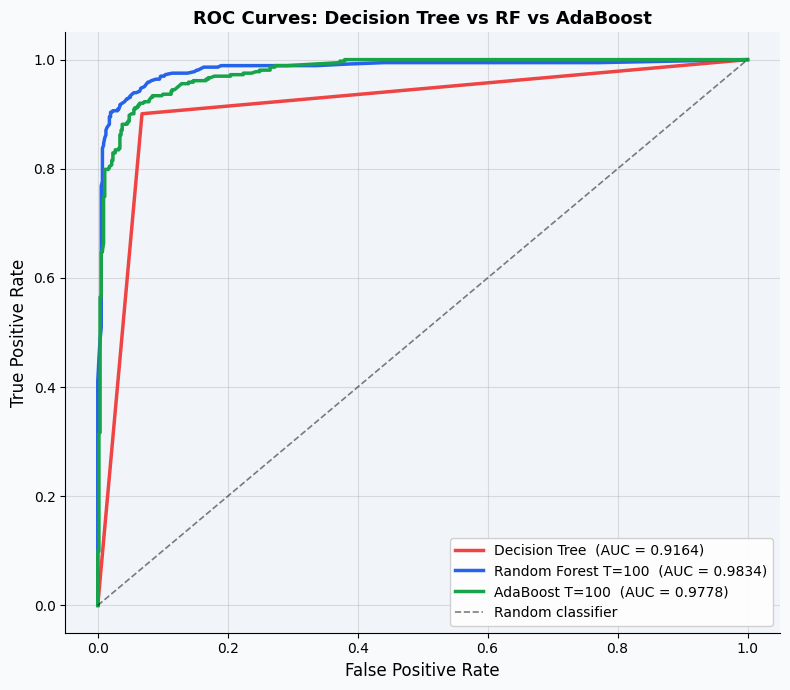

In [32]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
 
# Load and split data
df = pd.read_csv("/Users/etsub/Downloads/data/spambase.data", header=None)
X = df.iloc[:, :57].values
y = df.iloc[:, 57].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
 
def get_metrics(model, Xd, yd):
    yp  = model.predict(Xd)
    ypr = model.predict_proba(Xd)[:, 1]
    return dict(
        accuracy = round(accuracy_score(yd, yp), 4),
        f1       = round(f1_score(yd, yp),       4),
        auc      = round(roc_auc_score(yd, ypr),  4),
    )
 
T_values = [10, 50, 100, 500]
 
# AdaBoost for T in {10, 50, 100, 500}
ada_results = {}
 
print(f"  Problem 3-1 : AdaBoost")
print(f"  {'T':>5}  {'Split':<6}  {'Accuracy':>10}  {'F1':>10}  {'AUC':>10}")
print(f"  {'-'*50}")
 
for T in T_values:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T, random_state=42
    )
    ada.fit(X_train, y_train)
    ada_results[T] = ada
    for split, Xd, yd in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        m = get_metrics(ada, Xd, yd)
        print(f"  {T:>5}  {split:<6}  {m['accuracy']:>10.4f}  {m['f1']:>10.4f}  {m['auc']:>10.4f}")
    print(f"  {'-'*50}")
 
# AdaBoost vs Random Forest 
rf_results = {}
for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_results[T] = rf
 
print(f"  AdaBoost vs Random Forest – TEST SET")
print(f"  {'Model':<22}  {'T':>5}  {'Accuracy':>10}  {'F1':>10}  {'AUC':>10}")
print(f"  {'-'*62}")
for T in T_values:
    m_ada = get_metrics(ada_results[T], X_test, y_test)
    m_rf  = get_metrics(rf_results[T],  X_test, y_test)
    print(f"  {'AdaBoost':<22}  {T:>5}  {m_ada['accuracy']:>10.4f}  {m_ada['f1']:>10.4f}  {m_ada['auc']:>10.4f}")
    print(f"  {'Random Forest':<22}  {T:>5}  {m_rf['accuracy']:>10.4f}  {m_rf['f1']:>10.4f}  {m_rf['auc']:>10.4f}")
    print(f"  {'-'*62}")
 
# ROC curves
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)
 
models = {
    "Decision Tree":       dt,
    "Random Forest T=100": rf_results[100],
    "AdaBoost T=100":      ada_results[100],
}
colors = ["#EF4444", "#2563EB", "#16A34A"]
 
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F1F5F9")
 
for (name, model), color in zip(models.items(), colors):
    ypr = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, ypr)
    auc = roc_auc_score(y_test, ypr)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f"{name}  (AUC = {auc:.4f})")
 
ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves: Decision Tree vs RF vs AdaBoost", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
plt.show()

Problem 4

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# mushroom data
df = pd.read_csv("/Users/etsub/Downloads/data/agaricus-lepiota.data", header=None)
X_raw = df.iloc[:, 1:].values
y_raw = df.iloc[:, 0].values 

# Encode features as integers for both implementations
enc = OrdinalEncoder()
X = enc.fit_transform(X_raw).astype(int)
y = (y_raw == 'p').astype(int)   # 1 = poisonous, 0 = edible

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4-1
class NaiveBayes:
    def fit(self, X, y, alpha=1.0):
        self.classes   = np.unique(y)
        self.alpha     = alpha
        n              = len(y)
        # Prior probabilities P(Y=c)
        self.priors = {c: np.sum(y == c) / n for c in self.classes}
        # Conditional probabilities P(Xi=x | Y=c) with Laplace smoothing
        self.cond = {}
        for c in self.classes:
            Xc = X[y == c]
            self.cond[c] = []
            for j in range(X.shape[1]):
                n_vals   = int(X[:, j].max()) + 1
                counts   = np.bincount(Xc[:, j], minlength=n_vals).astype(float)
                probs    = (counts + alpha) / (len(Xc) + alpha * n_vals)
                self.cond[c].append(probs)
        return self

    def predict_proba(self, X):
        probs = []
        for x in X:
            scores = {}
            for c in self.classes:
                log_p = np.log(self.priors[c])
                for j, val in enumerate(x):
                    # Clip val in case test set has unseen category
                    v      = min(val, len(self.cond[c][j]) - 1)
                    log_p += np.log(self.cond[c][j][v])
                scores[c] = log_p
            # Convert log-scores to probabilities
            max_score = max(scores.values())
            exp_scores = {c: np.exp(scores[c] - max_score) for c in self.classes}
            total = sum(exp_scores.values())
            probs.append([exp_scores[c] / total for c in self.classes])
        return np.array(probs)

    def predict(self, X):
        return self.classes[np.argmax(self.predict_proba(X), axis=1)]

nb_custom = NaiveBayes().fit(X_train, y_train)

# prior probabilities
print(f"  4-1: Prior Probabilities (from training data)")
print(f"  P(Edible)    = {nb_custom.priors[0]:.4f}")
print(f"  P(Poisonous) = {nb_custom.priors[1]:.4f}")

# conditional probs for feature 0
print(f"\n  Sample – P(Feature_0 = x | Class) [with Laplace smoothing]:")
for val, pe, pp in zip(range(len(nb_custom.cond[0][0])),
                       nb_custom.cond[0][0], nb_custom.cond[1][0]):
    print(f"    x={val}  P(.|Edible)={pe:.4f}  P(.|Poisonous)={pp:.4f}")

# 4-2 & 4-3
y_pred_custom = nb_custom.predict(X_test)

def print_metrics(y_true, y_pred, label):
    print(f"  {label}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred):.4f}")

print_metrics(y_test, y_pred_custom, "4-3: Custom Naive Bayes – Test Set")

# 4-4
nb_sklearn = CategoricalNB(alpha=1.0)
nb_sklearn.fit(X_train, y_train)
y_pred_sklearn = nb_sklearn.predict(X_test)

print_metrics(y_test, y_pred_sklearn, "4-4: sklearn CategoricalNB – Test Set")

# Side-by-side comparison
print(f"  Comparison: Custom NB vs sklearn CategoricalNB")
print(f"  {'Metric':<14} {'Custom NB':>12} {'sklearn NB':>12}")
print(f"  {'-'*42}")
for metric, fn in [("Accuracy",  accuracy_score),
                   ("Precision", precision_score),
                   ("Recall",    recall_score),
                   ("F1 Score",  f1_score)]:
    custom_val  = fn(y_test, y_pred_custom)
    sklearn_val = fn(y_test, y_pred_sklearn)
    print(f"  {metric:<14} {custom_val:>12.4f} {sklearn_val:>12.4f}")

  4-1: Prior Probabilities (from training data)
  P(Edible)    = 0.5180
  P(Poisonous) = 0.4820

  Sample – P(Feature_0 = x | Class) [with Laplace smoothing]:
    x=0  P(.|Edible)=0.0936  P(.|Poisonous)=0.0129
    x=1  P(.|Edible)=0.0003  P(.|Poisonous)=0.0017
    x=2  P(.|Edible)=0.3751  P(.|Poisonous)=0.3955
    x=3  P(.|Edible)=0.0547  P(.|Poisonous)=0.1485
    x=4  P(.|Edible)=0.0079  P(.|Poisonous)=0.0003
    x=5  P(.|Edible)=0.4684  P(.|Poisonous)=0.4410
  4-3: Custom Naive Bayes – Test Set
  Accuracy  : 0.9527
  Precision : 0.9911
  Recall    : 0.9101
  F1 Score  : 0.9489
  4-4: sklearn CategoricalNB – Test Set
  Accuracy  : 0.9527
  Precision : 0.9911
  Recall    : 0.9101
  F1 Score  : 0.9489
  Comparison: Custom NB vs sklearn CategoricalNB
  Metric            Custom NB   sklearn NB
  ------------------------------------------
  Accuracy             0.9527       0.9527
  Precision            0.9911       0.9911
  Recall               0.9101       0.9101
  F1 Score             0